In [187]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import pingouin
import matplotlib.pyplot as plt
import seaborn as sns
from PlanningDynamics import utils, plotting, graph
from PlanningDynamics.dataClass import nwbWrapper
from sklearn.linear_model import LinearRegression

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
fnames = utils.get_filenames()

In [6]:
def condition_averaged_spikes(X, y):
    conditions = np.unique(y)
    n_conditions = len(conditions)
    _, n_timesteps, n_neurons = X.shape
    condition_average = np.zeros((n_conditions, n_timesteps, n_neurons))
    for i, cond in enumerate(conditions):
        idx = np.where(y == cond)[0]
        condition_average[i, ...] = np.mean(X[idx, ...], axis=0)
    return condition_average, conditions

def get_spikes(fname):
    data = nwbWrapper(fname, region="OFC", to_load="all")      
    y_choice = utils.distance_to_value(data.choice_df.graph_distance.values)
    X_choice = data.choice_spikes

    plans = data.get_plan_spikes(type="psth", min_duration=100, active_prob_threshold=0.2)
    y_plan = utils.distance_to_value(plans["df"].graph_distance.values)
    X_plan = plans["spikes"]
    
    choice_avg, choice_cond = condition_averaged_spikes(X_choice, y_choice)
    plan_avg, plan_cond = condition_averaged_spikes(X_plan, y_plan)
    return dict(choice_avg=choice_avg, choice_cond=choice_cond, 
                plan_avg=plan_avg, plan_cond=plan_cond)

In [7]:
condition_averages = utils.iterate_subjects(fnames, get_spikes)

Processing bart:   0%|          | 0/8 [00:00<?, ?it/s]

loading trial data:
loading trials:


100%|██████████| 563/563 [00:00<00:00, 600.31it/s]


loading choice data:


Processing bart:  12%|█▎        | 1/8 [00:06<00:43,  6.15s/it]

...

Processing london:  86%|████████▌ | 6/7 [00:54<00:08,  8.99s/it]

loading trial data:
loading trials:


100%|██████████| 943/943 [00:01<00:00, 627.71it/s]


loading choice data:


Processing london: 100%|██████████| 7/7 [01:05<00:00,  9.33s/it]


In [24]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA as sklearnPCA

def scaledPCA(n_components=20):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('pca', sklearnPCA(n_components=n_components))
    ])
    
def fit_PCA(cond_avg, n_components, bin_size, step_size):
    model = scaledPCA(n_components=n_components)
    n_cond, n_timesteps, n_neurons = cond_avg.shape
    n_bins = int(n_timesteps / step_size)
    X = np.zeros([n_cond, n_bins, n_neurons])
    for i in range(n_bins):
        start = i * step_size
        end = np.minimum(start + bin_size, n_timesteps)
        X[:, i, :] = np.mean(cond_avg[:, start:end, :].astype(float), axis=1)
    X = X.reshape(n_cond * n_bins, n_neurons)
    PCs = model.fit_transform(X)
    PCs = PCs.reshape(n_cond, n_bins, n_components)
    return model, PCs, X, (n_cond, n_bins, n_components)

def projected_response(X, model):
    scaled_X = model["scaler"].transform(X)
    projected_X = model["pca"].transform(scaled_X)
    var_explained = np.diag(np.cov(projected_X.T)) / np.diag(np.cov(scaled_X.T)).sum()    
    return dict(projection=projected_X, var_explained=var_explained)


In [34]:
class PCA:
    def __init__(self, n_components=20, bin_size=150, step_size=10):
        self.n_components = n_components
        self.bin_size = bin_size
        self.step_size = step_size
        self.model = self.scaledPCA()

    def scaledPCA(self):
        return Pipeline([
            ('scaler', StandardScaler()),
            ('pca', sklearnPCA(n_components=self.n_components))
        ])

    
    def reshape_(self, X):
        return X.reshape(self.n_cond, self.n_bins, -1)

    def fit(self, cond_avg):
        self.n_cond, self.n_timesteps, self.n_neurons = cond_avg.shape
        self.n_bins = int(self.n_timesteps / self.step_size)
        X = np.zeros([self.n_cond, self.n_bins, self.n_neurons])
        for i in range(self.n_bins):
            start = i * self.step_size
            end = np.minimum(start + self.bin_size, self.n_timesteps)
            X[:, i, :] = np.mean(cond_avg[:, start:end, :].astype(float), axis=1)
        self.X = X.reshape(self.n_cond * self.n_bins, self.n_neurons)
        PCs = self.model.fit_transform(self.X)
        self.PCs = self.reshape_(PCs)
        #return self.PCs, self.X

    def projected_response(self, X):
        scaled_X = self.model["scaler"].transform(X)
        projected_X = self.model["pca"].transform(scaled_X)
        var_explained = np.diag(np.cov(projected_X.T)) / np.diag(np.cov(scaled_X.T)).sum()    
        return dict(projection=projected_X, var_explained=var_explained)

In [28]:
condition_averages["london"][0]["choice_avg"].shape

(4, 1000, 104)

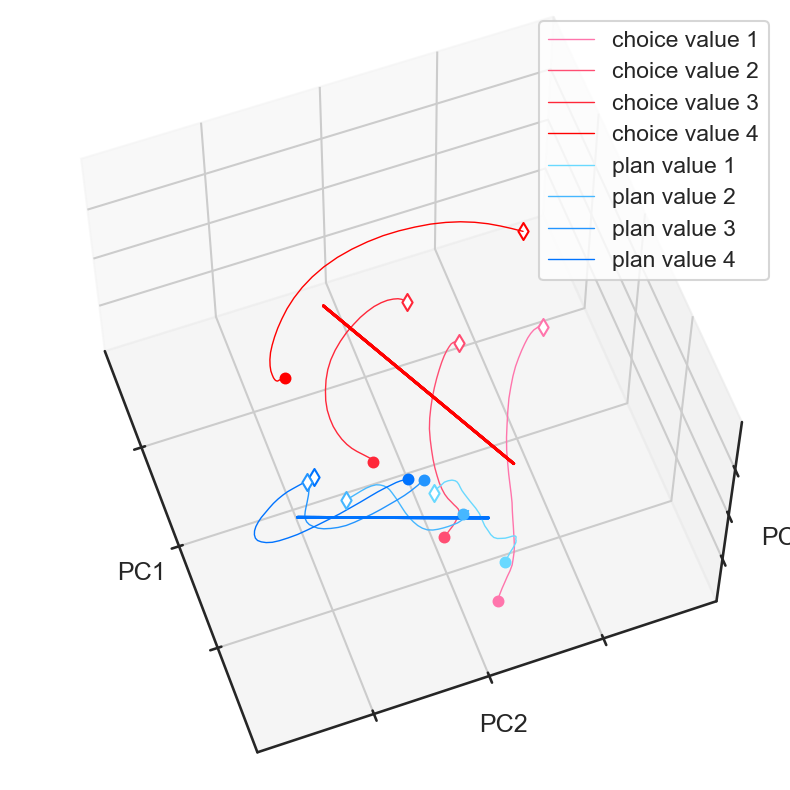

In [203]:
from matplotlib.colors import LinearSegmentedColormap
def interpolate_colors(color1, color2, num_colors):
    cmap = LinearSegmentedColormap.from_list('custom_cmap', [color1, color2], N=num_colors)
    colors = [cmap(i) for i in range(num_colors)]
    return colors

def fig4b(condition_averages):
    sbj = "london"
    choice_avg = np.concat([a["choice_avg"] for a in condition_averages[sbj]], axis=2)
    plan_avg = np.concat([a["plan_avg"] for a in condition_averages[sbj]], axis=2)
    full_avg = np.concat([choice_avg, plan_avg], axis=0)
    conditions = {}
    for i in range(4):
        conditions[i]  = "choice value " + str(i + 1)
        conditions[i + 4] = "plan value " + str(i + 1)
    pca = PCA(n_components=10, bin_size=150, step_size=10)
    pca.fit(full_avg)
    
    sns.set(style="ticks", context="talk", palette="tab10")

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    PCs = pca.PCs.copy()

    l_start, l_end = 45, 85
    t_start = 50
    t_end = 80
    choice_colors = interpolate_colors(color2="#ff0000", color1="#ff75ac", num_colors=4)#[::-1]
    plan_colors = interpolate_colors(color2="#0073ff", color1="#69d9ff", num_colors=4)#[::-1]
    colors_all = np.vstack([choice_colors, plan_colors])

    for i in range(8):
        trace = utils.movmean(PCs[i, l_start:l_end, :].T, w=2).T
        c = colors_all[i]
        ax.plot(trace[:, 0], trace[:, 1], trace[:, 2], color=c, alpha=1, linestyle="-", lw=1, label=conditions[i])
        ax.scatter(trace[0, 0], trace[0, 1], trace[0, 2], color=c, s=50, alpha=1)
        ax.scatter(trace[-1, 0], trace[-1, 1], trace[-1, 2], s=75, alpha=1, marker="d", facecolor="white", edgecolor=c)

        mean_pcs_exe = PCs[:4, t_start:t_end, :].mean(axis=1)
        mean_pcs_plan = PCs[4:, t_start:t_end, :].mean(axis=1)    

        def plot_linear_regression(ax, mean_pcs, colors):
            model = LinearRegression().fit(mean_pcs[:, [0, 1]], mean_pcs[:, 2])
            exe_coef = model.coef_.copy()
            exe_intercept = model.intercept_

            X, Y = np.linspace(mean_pcs[0, 0], mean_pcs[3, 0]), np.linspace(mean_pcs[0, 1], mean_pcs[3, 1])
            Z = exe_coef[0] * X + exe_coef[1] * Y + exe_intercept
            ax.plot(X, Y, Z, color=colors[-1], lw=2)
            return

        plot_linear_regression(ax, mean_pcs_exe, choice_colors)
        plot_linear_regression(ax, mean_pcs_plan, plan_colors)

        ax.set_xlim([-20, 40])
        ax.set_ylim([-30, 30])
        ax.set_zlim([-30, 40])

        ax.set_xlabel("PC%i" % 1)
        ax.set_ylabel("PC%i" % 2)
        ax.set_zlabel("PC%i" % 3)

    ax.set_xticks([-5, 10, 25], labels=["", "", ""])
    ax.set_yticks([-30 + 15 , -30 + 30, -30 + 45], labels=["", "", ""])
    ax.set_zticks([-30 + 70/4, -30 + 140/4, -30 + 210/4], labels=["", "", ""])    
    ax.legend()
    ax.view_init(60, 160) 
    
    return pca, conditions

pca, conditions = fig4b(condition_averages)

In [204]:
PC_models = {}
for sbj in condition_averages:
    PC_models[sbj] = {}
    for cond in ["choice", "plan"]:
        key = cond + "_avg"
        X = np.concat([a[key] for a in condition_averages[sbj]], axis=2)
        model = PCA(n_components=10, bin_size=150, step_size=10)
        model.fit(X)
        PC_models[sbj][cond] = model

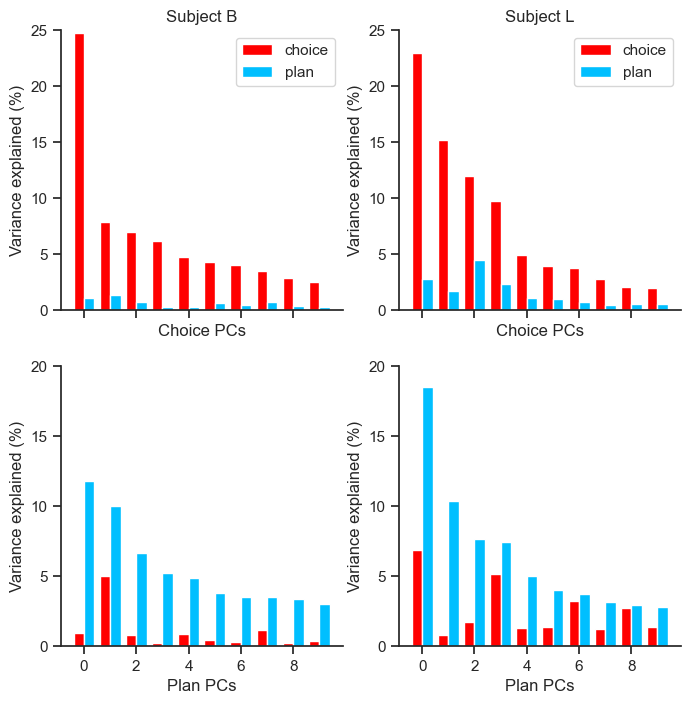

In [209]:
sns.set(style="ticks")
fig, axes = plt.subplots(2, 2, figsize=(8, 8), sharey=False, sharex=True)
sns.despine()

for i, sbj in enumerate(PC_models):
    choice = PC_models[sbj]["choice"]
    plan = PC_models[sbj]["plan"]
    choice_to_choice = choice.projected_response(choice.X)
    plan_to_choice = choice.projected_response(plan.X)
    
    plan_to_plan = plan.projected_response(plan.X)
    choice_to_plan = plan.projected_response(choice.X)
    
    n_components = 10
    w = 0.4
    x_choice = np.arange(0, n_components) - w/2
    x_plan = np.arange(0, n_components) + w/2
    ax = axes[:, i]
    c_choice = "red"
    c_plan = "deepskyblue"
    
    # Projection into choice subspace
    ax[0].bar(x_choice, choice_to_choice["var_explained"]*100, width=w, label="choice", color=c_choice)
    ax[0].bar(x_plan, plan_to_choice["var_explained"]*100, width=w, label="plan", color=c_plan)
    ax[0].set_ylim([0, 25])
    ax[0].legend()
    ax[0].set_xlabel("Choice PCs")
    ax[0].set_title("Subject %s" % sbj[0].capitalize())
    
    # Projection into plan subspace
    ax[1].bar(x_choice, choice_to_plan["var_explained"]*100, width=w, label="choice", color=c_choice)
    ax[1].bar(x_plan, plan_to_plan["var_explained"]*100, width=w, label="plan", color=c_plan)
    ax[1].set_ylim([0, 20])
    ax[1].set_yticks([0, 5, 10, 15, 20])
    ax[1].set_xlabel("Plan PCs")
    ax[0].set_ylabel("Variance explained (%)")
    ax[1].set_ylabel("Variance explained (%)")

In [212]:
for sbj in PC_models:
    choice, plan = PC_models[sbj]["choice"], PC_models[sbj]["plan"]
    def cross_model_alignment(model1, model2):
        Q = model1.model["pca"].components_
        C = model2.model["pca"].get_covariance()
        lam = model2.model["pca"].singular_values_
        alignment = np.diag(Q @ C @ Q.T).sum()/lam.sum()
        return alignment
    PC_models[sbj]["plan_to_choice_alignment"] = cross_model_alignment(choice, plan)
    PC_models[sbj]["choice_to_plan_alignment"] = cross_model_alignment(plan, choice)

In [206]:
#sbj_alignment = plan_to_choice[1].sum()/plan_to_plan[1].sum()
"""
Q = choice_pcs[0]["pca"].components_
C = plan_pcs[0]["pca"].get_covariance()
lam = plan_pcs[0]["pca"].singular_values_
sbj_alignment = np.diag(Q @ C @ Q.T).sum()/lam.sum()
plan_to_choice_alignment[sbj] = sbj_alignment

Q = plan_pcs[0]["pca"].components_
C = choice_pcs[0]["pca"].get_covariance()
lam = choice_pcs[0]["pca"].singular_values_
sbj_alignment = np.diag(Q @ C @ Q.T).sum()/lam.sum()
choice_to_plan_alignment[sbj] = sbj_alignment
"""
#sbj_alignment = np.linalg.norm(Q_plan @ Q_choice.T, "fro")/10

{'projection': array([[-15.91683074,  14.83119409,   1.08994258, ...,  -6.71986471,
           1.01526905,   8.05706434],
        [-16.00054059,  14.49904344,   0.88688741, ...,  -7.25599464,
           0.96857844,   8.12271122],
        [-15.73535509,  14.98712823,   0.99992112, ...,  -7.50983817,
           0.87446944,   8.38680029],
        ...,
        [ 31.32112401,  13.43024575,  18.3669368 , ...,   4.77568231,
          11.91403804,  -4.89894758],
        [ 30.71498357,  14.9991584 ,  18.88413701, ...,   2.43342648,
          14.11631866,  -6.52530288],
        [ 31.24234815,  14.55144768,  18.58378411, ...,   1.50854367,
          16.94182718,  -6.70124083]]),
 'var_explained': array([0.24797031, 0.07916345, 0.0702782 , 0.06150655, 0.04717301,
        0.04342052, 0.04069356, 0.03518762, 0.02908675, 0.02522754])}